<a href="https://colab.research.google.com/github/miajags/EMSC2010-W10_P2_sine-waves-and-frequency/blob/main/EMSC2010_W10_P1_NB2_fast_Fourier_transform%2C_filters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010-W10-P1-NB2
In this notebook we'll use the Fourier transform to decompose a signal into sinusoids and represent that information in a frequency spectrum.

We'll also see how to modify the frequency spectrum to filter out parts of the signal that we are not interested in.

Start by importing the packages we'll need.

In [1]:
import numpy as np #numpy for numerical operations
import matplotlib.pyplot as plt #matplotlib for plotting

First, we'll recreate the composite signal that we constructed in EMSC2010-W10-P1-NB1, which is made up of 3 sinusoids.

Text(0, 0.5, 'Signal')

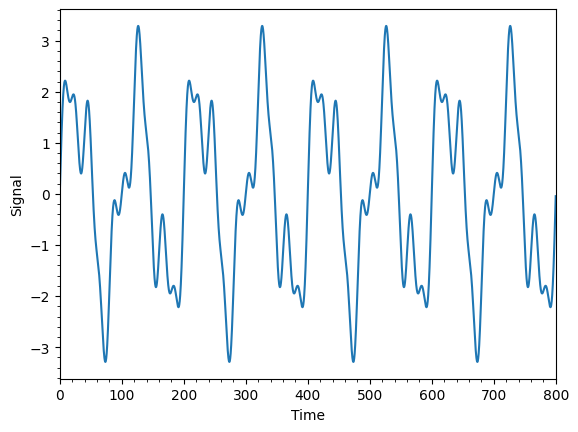

In [2]:
time = np.arange(0,800,0.1) #generate times with a spacing of 0.1 between 0 and 799
f1 = 1/100 #frequency of the 1st signal
f2 = 1/40 #frequency of the 2nd signal
f3 = 1/20 #frequency of the 3rd signal

A1 = 2 #amplitude of the 1st signal
A2 = 1 #amplitude of the 2nd signal
A3 = 0.5 #amplitude of the 3rd signal

signal1 = np.sin(2*np.pi*f1*time)*A1 #first signal
signal2 = np.sin(2*np.pi*f2*time)*A2 #second signal
signal3 = np.sin(2*np.pi*f3*time)*A3 #third signal
signal = signal1 + signal2 + signal3 #combine the signals

plt.plot(time,signal) #plot the signal
plt.xlim([0,800]) #limit the x-axis
plt.minorticks_on() #add minorticks
plt.xlabel('Time') #label the x-axis
plt.ylabel('Signal') #label the y-axis

I've written the function below to calculate the Fourier transform and output the results for plotting.

Importantly, the Fourier transform requires data to be equally spaced in time. Therefore, I've included an interpolation step to do this.

In [3]:

def freq_spectrum(time,signal):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT (positive freqs only)
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  # Amplitude: scale by 2/n so each peak height equals the true amplitude
  amplitude = (2 / n) * np.abs(fft_vals)
  amplitude[0] /= 2

  return freqs, amplitude

We can now call the function ```freq_spectrum``` with our time and signal arrays.


Once we have the outputs (frequencies and amplitudes) we can plot them in a so-called frequency spectrum.

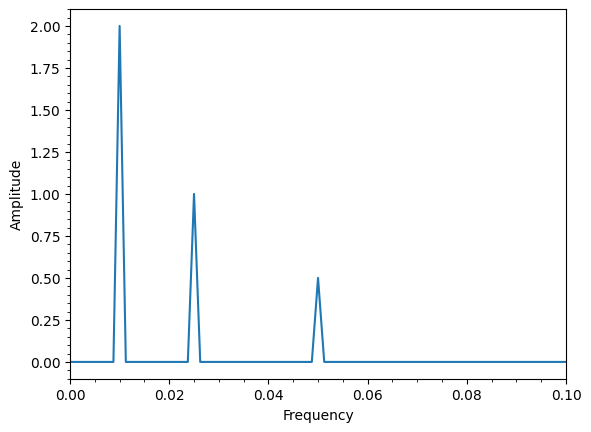

In [4]:
freqs, amplitude = freq_spectrum(time,signal) #get the frequency spectrum
plt.plot(freqs,amplitude) #plot the frequency spectrum
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.xlim([0,0.1]) #limit the x-axis
plt.minorticks_on() #add minorticks

Now imagine that we are only interested in the lower frequency part of our signal. This means we'll need to *filter* out the higher frequency sinusoids.

We can do this by calculating the frequency spectrum and then reducing to zero the amplitudes of sinusoids at frequencies we want to filter out. Once this is done we can use the *inverse* Fourier transform to convert back to the time domain.

If we are removing higher frequency sinusoids we use a *low pass* filter which will let the low frequencies pass, but block the high frequencies.

The frequency that represents the threshold between keeping and removing sinusoids is called the *cutoff* frequency.

The function below is a (very) simple low pass filter.

In [8]:
def lowpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT, amplitudes
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs>cutoff] = 0.0 #cycles above the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT, inverse fourier transform, turn it back into a sin signal

  return x, filtered_signal

Let's filter any sinusoids with a frequency greater than 0.02 out of our composite signal. We'll then plot the result.

Text(0, 0.5, 'Filtered signal')

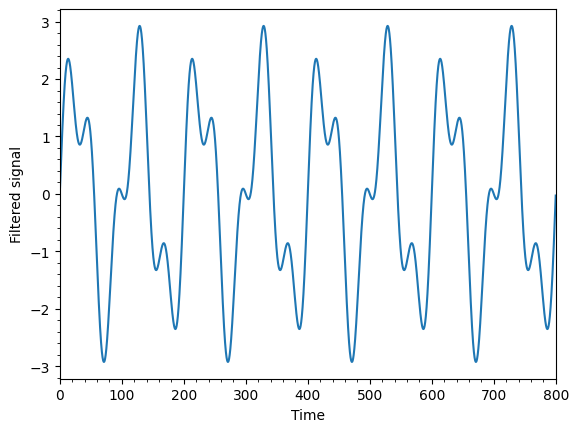

In [14]:
x, filtered_signal = lowpass_filter(time,signal,0.04) #perform the filtering
plt.plot(x,filtered_signal) #plot the filtered signal
plt.xlim([0,800]) #limit the x-axis
plt.minorticks_on() #add minorticks
plt.xlabel('Time') #label the x-axis
plt.ylabel('Filtered signal') #label the y-axis

#what wheels do we delete, and which ones do we keep? setting the cutoff.

Now try changing the cutoff frequency to see how it controls the filtered signal.